#Inflation Model

In [1]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.dynamic_factor import DynamicFactor
from sklearn.metrics import mean_squared_error
import warnings
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

warnings.simplefilter("ignore")

In [2]:
SRC_INF = "Inflation_monthly_combined.xlsx"
SRC_CPI = "CPIAUCSL.xlsx"
SHEET   = "Smoothed_Monthly"

np.random.seed(0)

def load_cpi(src=SRC_CPI):
    raw = pd.read_excel(src, sheet_name="Monthly")
    raw["date"] = (pd.to_datetime(raw["observation_date"])
                   .dt.to_period("M").dt.to_timestamp("M"))
    return raw.set_index("date")["CPIAUCSL"].rename("cpi_level").sort_index()


def load_panel(src=SRC_INF, sheet=SHEET):
    raw = pd.read_excel(src, sheet_name=sheet, index_col=0, parse_dates=True)
    panel = pd.DataFrame({
        "ppi_level": raw["PPI"],
        "ahe_level": raw["AHE"],
        "oil_level": raw["OIL_AVG"],
        "rent_level": raw["RENT"],
        "inf_exp_1y": raw["NYFED_EXP"],
        "breakeven_10y": raw["T10YIE_AVG"],
        "breakeven_5y": raw["T5YIE_AVG"],
        "gscpi": raw["GSCPI"],
    })
    panel.index.name = "date"
    panel = panel.join(load_cpi(), how="left")
    return panel.sort_index()

def transform(panel, start="2003-01-31", end="2026-08-31"):
    panel = panel[panel.index <= end]
    tf = pd.DataFrame(index=panel.index)
    tf["ppi_yoy"] = 100 * (panel["ppi_level"]  / panel["ppi_level"].shift(12)  - 1)
    tf["ahe_yoy"] = 100 * (panel["ahe_level"]  / panel["ahe_level"].shift(12)  - 1)
    tf["oil_yoy"] = 100 * (panel["oil_level"]  / panel["oil_level"].shift(12)  - 1)
    tf["rent_yoy"] = 100 * (panel["rent_level"] / panel["rent_level"].shift(12) - 1)
    tf["inf_exp_1y"] = panel["inf_exp_1y"]
    tf["breakeven_10y"] = panel["breakeven_10y"]
    tf["breakeven_5y"] = panel["breakeven_5y"]
    tf["gscpi"] = panel["gscpi"]
    tf["cpi_yoy"] = 100 * (panel["cpi_level"]  / panel["cpi_level"].shift(12)  - 1)
    tf.index.name = "date"
    # asfreq reindexes to a perfectly regular ME spine (fills holes with NaN)
    return tf.loc[start:end].asfreq("ME")

def _bootstrap_params(tf):
    init = tf.loc["2016-01-31":"2019-12-31"].dropna()
    means_i, stds_i = init.mean(), init.std()
    z_init = (init - means_i) / stds_i
    mod_i = DynamicFactor(z_init, k_factors=1, factor_order=2,
                          error_order=1, error_cov_type="diagonal")
    res_i = mod_i.fit(method="powell", maxiter=400, disp=False)
    return res_i.params

def fit_dfm(z_train, start_params=None):
    z_train = z_train.copy()
    z_train.index.freq = "ME"
    mod = DynamicFactor(
        z_train,
        k_factors=1,
        factor_order=2,
        error_order=1,
        error_cov_type="diagonal",
    )
    if start_params is None:
        res = mod.fit(method="powell", maxiter=500, disp=False)
        res = mod.fit(start_params=res.params, method="lbfgs", maxiter=1000, disp=False)
    else:
        res = mod.fit(start_params=start_params, method="lbfgs", maxiter=500, disp=False)
    return mod, res

def rolling_window(df, train_window_size=225, rolling=False):
    n_obs = len(df)
    test_dates    = []
    actual_cpi    = []
    pred_cpi      = []

    bootstrap_params = _bootstrap_params(df)
    last_params = bootstrap_params

    for t in range(train_window_size, n_obs):
        start_idx   = t - train_window_size if rolling else 0
        train_df    = df.iloc[start_idx:t]
        test_obs    = df.iloc[t]
        target_date = df.index[t]

        train_means = train_df.mean()
        train_stds  = train_df.std()
        z_train     = (train_df - train_means) / train_stds

        try:
            mod, res = fit_dfm(z_train, start_params=last_params)
            last_params = res.params
        except Exception:
            try:
                mod, res = fit_dfm(z_train, start_params=bootstrap_params)
                last_params = res.params
            except Exception:
                continue   # skip this step if both attempts fail

        factor_1step  = res.get_prediction(
            start=len(z_train), end=len(z_train)
        ).predicted_mean

        cpi_z_pred        = factor_1step["cpi_yoy"].iloc[0]
        cpi_pred_unscaled = cpi_z_pred * train_stds["cpi_yoy"] + train_means["cpi_yoy"]

        test_dates.append(target_date)
        actual_cpi.append(test_obs["cpi_yoy"])
        pred_cpi.append(cpi_pred_unscaled)

    out_df = pd.DataFrame(
        {"cpi_actual": actual_cpi, "cpi_forecast": pred_cpi},
        index=pd.to_datetime(test_dates),
    )
    return out_df

if __name__ == "__main__":
    panel = load_panel()
    tf    = transform(panel)

    oos_results = rolling_window(tf, train_window_size=225, rolling=False)

    # Drop any rows where actual CPI YoY was NaN (the 2025-10 gap)
    oos_clean = oos_results.dropna(subset=["cpi_actual"])

    rmse = np.sqrt(mean_squared_error(oos_clean["cpi_actual"], oos_clean["cpi_forecast"]))
    corr = oos_clean[["cpi_actual", "cpi_forecast"]].corr().iloc[0, 1]

    print("\nOut-of-Sample Test Results:")
    print(f"  Out-of-Sample RMSE:        {rmse:.3f}")

Total observations:  284
Total test periods:  59

Out-of-Sample Test Results:
  Out-of-Sample RMSE:        0.435


In [3]:
def generate_cpi_forecast(df, steps=9, target_col="cpi_yoy", alpha=0.05):
    if target_col not in df.columns:
        raise KeyError(
            f"Target column '{target_col}' not found in DataFrame. "
            f"Existing columns: {list(df.columns)}. "
            f"Make sure you passed the inflation dataset (e.g., tf_inf) and not the ISM dataset."
        )

    means = df.mean()
    stds = df.std()
    z_df = (df - means) / stds

    # Bootstrap initial parameters to ensure stable convergence
    bootstrap_params = _bootstrap_params(df)
    _, res = fit_dfm(z_df, start_params=bootstrap_params)

    forecast_res = res.get_forecast(steps=steps)
    z_pred_mean = forecast_res.predicted_mean
    z_conf_int = forecast_res.conf_int(alpha=alpha)

    # Invert z-score scaling back to original percentage units
    target_mean = means[target_col]
    target_std = stds[target_col]

    fc_df = pd.DataFrame(
        {
            "forecast": z_pred_mean[target_col] * target_std + target_mean,
            "lower_ci": z_conf_int[f"lower {target_col}"] * target_std
            + target_mean,
            "upper_ci": z_conf_int[f"upper {target_col}"] * target_std
            + target_mean,
        },
        index=z_pred_mean.index,
    )

    return fc_df


def plot_cpi_forecast(
    df, fc_df, target_col="cpi_yoy", history_months=24, show_target_line=True
):
    recent_history = df[target_col].iloc[-history_months:].dropna()

    fig, ax = plt.subplots(figsize=(11, 5.5), dpi=120)

    # Historical series
    ax.plot(
        recent_history.index,
        recent_history.values,
        label="Historical CPI YoY (%)",
        color="#1f77b4",
        linewidth=2.2,
    )

    # Stitch the last historical point to the forecast path for continuity
    plot_dates = [recent_history.index[-1]] + list(fc_df.index)
    plot_forecast = [recent_history.values[-1]] + list(fc_df["forecast"])
    plot_lower = [recent_history.values[-1]] + list(fc_df["lower_ci"])
    plot_upper = [recent_history.values[-1]] + list(fc_df["upper_ci"])

    # Forecast line and uncertainty band
    ax.plot(
        plot_dates,
        plot_forecast,
        label=f"{len(fc_df)}-Month Forecast",
        color="#d62728",
        linewidth=2.2,
        linestyle="--",
        marker="o",
    )
    ax.fill_between(
        plot_dates,
        plot_lower,
        plot_upper,
        color="#d62728",
        alpha=0.15,
        label="95% Confidence Interval",
    )

    # Label points on the forecasted line
    for dt, val in zip(fc_df.index, fc_df["forecast"]):
        ax.annotate(
            f"{val:.2f}%",
            xy=(dt, val),
            xytext=(0, 9),
            textcoords="offset points",
            ha="center",
            fontsize=9,
            fontweight="bold",
            color="#a31d1d",
        )

    # Reference 2% Target
    if show_target_line:
        ax.axhline(
            2.0,
            color="darkgreen",
            linestyle=":",
            linewidth=1.2,
            alpha=0.8,
            label="2.0% Target",
        )

    ax.set_title(
        f"Headline CPI YoY: {len(fc_df)}-Month Out-of-Sample Forecast (DFM)",
        fontsize=13,
        fontweight="bold",
        pad=14,
    )
    ax.set_xlabel("Date", fontsize=11)
    ax.set_ylabel("Year-over-Year Change (%)", fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.grid(True, linestyle=":", alpha=0.55)
    ax.legend(loc="upper left", frameon=True)

    plt.tight_layout()
    plt.show()


--- Projected CPI YoY Values ---


,forecast,lower_ci,upper_ci
2026-09,3.32,2.45,4.19
2026-10,3.27,1.99,4.55
2026-11,3.21,1.61,4.80
2026-12,3.14,1.31,4.98
2027-01,3.08,1.06,5.10
2027-02,3.03,0.86,5.19
2027-03,2.98,0.70,5.26
2027-04,2.94,0.56,5.31
2027-05,2.90,0.45,5.35


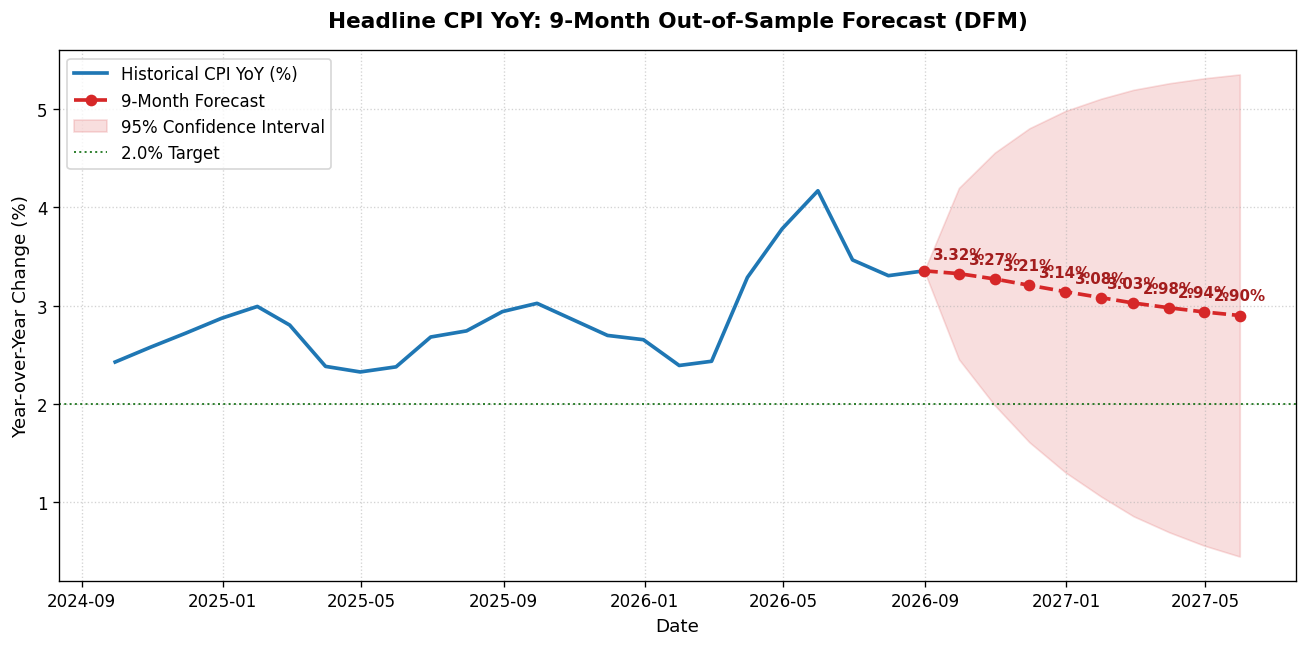

In [4]:
panel_inf = load_panel()
tf_inf2 = transform(panel_inf)

cpi_forecast_9m = generate_cpi_forecast(
    tf_inf2, steps=9, target_col="cpi_yoy", alpha=0.05
)

display_df = cpi_forecast_9m.copy()
display_df.index = display_df.index.strftime("%Y-%m")
display(display_df.round(2))

# 5. Render plot
plot_cpi_forecast(
    tf_inf2,
    cpi_forecast_9m,
    target_col="cpi_yoy",
    history_months=24,
    show_target_line=True,
)